# Bayesian analysis

Fitting with `fit()` finds the single set of parameter values that best matches the data, and reports an uncertainty derived from the curvature of $\chi^2$ at that point. That uncertainty is only trustworthy when the parameters are uncorrelated and their uncertainties are close to Gaussian, which in QENS is often not the case.

A **Bayesian** analysis answers a different question: instead of one best point, it maps out the whole *posterior distribution* over the parameters. From that you can read off credible intervals that stay honest when parameters are correlated or their distributions are skewed, and you can see the correlations directly.

EasyDynamics does this with the DREAM sampler from [BUMPS](https://bumps.readthedocs.io/), through `bayesian.sample()`.

In [1]:
import pooch

import easydynamics as edyn

# Make the plots interactive; the Q sliders need the widget backend
%matplotlib widget

## Load the data

We use the same artificial vanadium measurement as the [Analysis 1D](analysis1d.ipynb) tutorial, and analyse a single Q slice.

In [2]:
vanadium_experiment = edyn.Experiment('Vanadium')

file_path = pooch.retrieve(
    url='https://github.com/easyscience/dynamics-lib/raw/refs/heads/master/docs/docs/tutorials/data/vanadium_data_example.h5',
    known_hash='16cc1b327c303feeb88fb9dda5390dc4880b62396b1793f98c6fef0b27c7b873',
)

vanadium_experiment.load_hdf5(filename=file_path)

## Build the model and fit it

As in [Tutorial 1](tutorial1_brownian.ipynb), a vanadium measurement is modelled with the Gaussian as the *sample*: what is being measured is the resolution function itself, so there is nothing to convolve it with.

Sampling does not require a fit first, but it benefits from one: DREAM starts its chains in a small ball around the parameters' current values, so beginning from fitted values means less burn-in is needed before the chains reach the interesting region.

In [3]:
vanadium_components = edyn.ComponentCollection()
vanadium_components.append_component(edyn.Gaussian(width=0.1, area=1, name='Res. Gauss'))

instrument_model = edyn.InstrumentModel(
    background_model=edyn.BackgroundModel(components=edyn.Polynomial(coefficients=[0.001])),
)

analysis = edyn.Analysis1d(
    display_name='Vanadium Analysis',
    experiment=vanadium_experiment,
    sample_model=edyn.SampleModel(components=vanadium_components),
    instrument_model=instrument_model,
    Q_index=5,
)

fit_result = analysis.fit()
print(f'reduced chi-squared = {fit_result.reduced_chi2:.4f}')

reduced chi-squared = 0.3763


## Bounds are the prior

In DREAM, each parameter's `min` and `max` define a uniform prior, so **every free parameter must have finite bounds** before sampling. Most parameters start with at least one infinite bound, so `bayesian.sample()` would refuse to run.

`bayesian.suggest_bounds()` proposes bounds from the fitted values and uncertainties. It is advisory: it changes nothing until you call `.apply()`, and it only ever fills in an *infinite* bound, so physical limits you have already set (an area that cannot go below zero, say) are left alone.

In [4]:
suggestions = analysis.bayesian.suggest_bounds()
print(suggestions)

BoundsSuggestions
parameter                           current                  suggested
----------------------------------------------------------------------
Res. Gauss area                    (0, inf)                (0, 0.7857)
Res. Gauss width               (1e-10, inf)            (1e-10, 0.1467)
energy_offset                   (-inf, inf)        (-0.02955, 0.03213)
Polynomial_c0                   (-inf, inf)            (0.0617, 0.143)


The defaults are deliberately generous — 10 standard deviations plus 20% of the value. Because the bounds are a uniform prior, being too *narrow* is the dangerous mistake: it truncates the posterior and makes the uncertainty look smaller than it is. The 20% term is there for parameters whose fitted uncertainty comes back as zero. All three settings (`n_sigma`, `relative_pad`, `absolute_floor`) can be adjusted, and you can always set `min` and `max` by hand.

It is worth reading the table before applying it. A suggestion many orders of magnitude larger than the parameter itself is a useful warning sign: it means the fit returned a huge uncertainty, which usually happens because two parameters are **degenerate** — the data determines only some combination of them, so one can grow while the other shrinks with no effect on the fit. That is a problem to fix in the model, not with the sampler.

In [5]:
changed = suggestions.apply()
print(f'Applied bounds to: {[parameter.name for parameter in changed]}')

Applied bounds to: ['Res. Gauss area', 'Res. Gauss width', 'energy_offset', 'Polynomial_c0']


## Sample the posterior

`bayesian.sample()` runs the chains. The three numbers that matter are:

- `samples` — how many draws to collect in total. More is better, at linear cost.
- `burn` — generations discarded at the start, while the chains are still travelling towards the bulk of the posterior.
- `thin` — keep only every n-th generation, which reduces the correlation between neighbouring draws.

Sampling never moves your parameters: their values are restored afterwards, so the model is left exactly as the fit left it.

For a long run, `progress=True` shows a single self-updating line with the percentage of generations completed, closed with `Sampling: done`. The percentage is based on the backend's own estimate of the run length, which can be too high, so a finished run may close the line before reaching 100%.

In [6]:
results = analysis.bayesian.sample(samples=4000, burn=300, thin=2, progress=True)

print(f'Collected {results.draws.shape[0]} draws for {results.draws.shape[1]} parameters.')

Sampling:   0% (1/700 generations)

Sampling:   1% (7/700 generations)

Sampling:   2% (14/700 generations)

Sampling:   3% (21/700 generations)

Sampling:   4% (28/700 generations)

...

Sampling:  56% (392/700 generations)

Sampling:  57% (399/700 generations)

Sampling: done                      

Collected 1000 draws for 4 parameters.


/home/runner/work/dynamics-lib/dynamics-lib/.pixi/envs/default/lib/python3.14/site-packages/bumps/dream/convergence.py:186: UserWarning: Did not converge!
  warnings.warn("Did not converge!")


## Did the chains converge?

Always look at the traces before trusting the numbers. A converged chain looks like a "hairy caterpillar": noisy, but flat and stationary. A visible drift or slow wander means the chain has not settled and needs a longer burn-in or more samples.

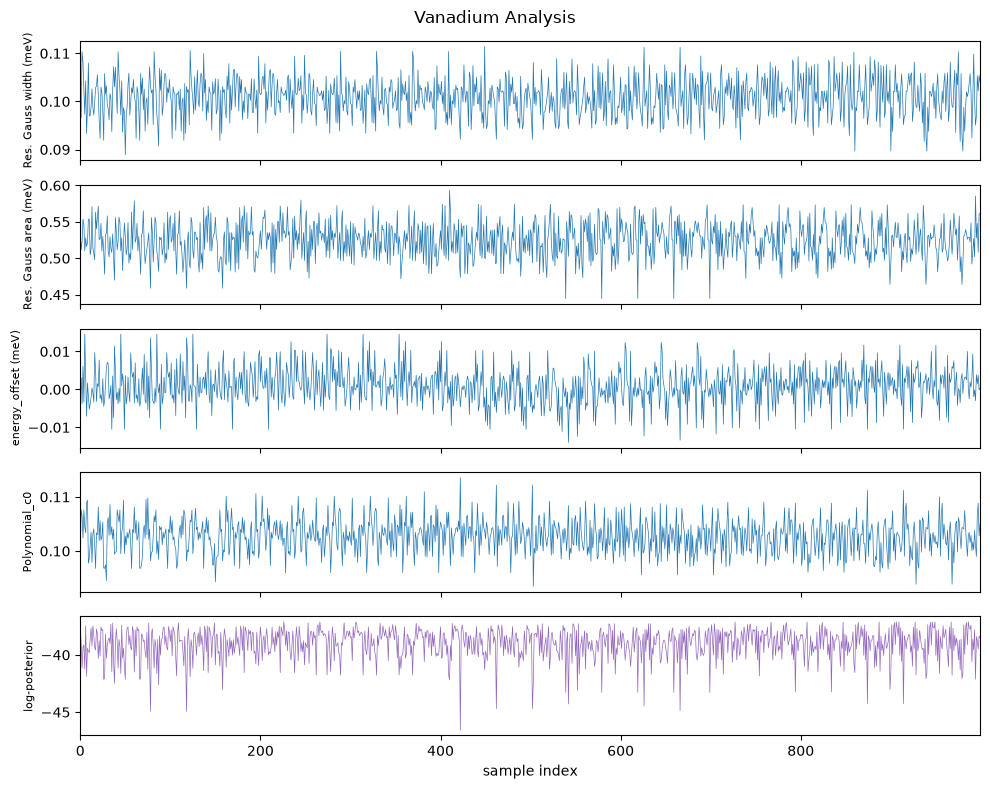

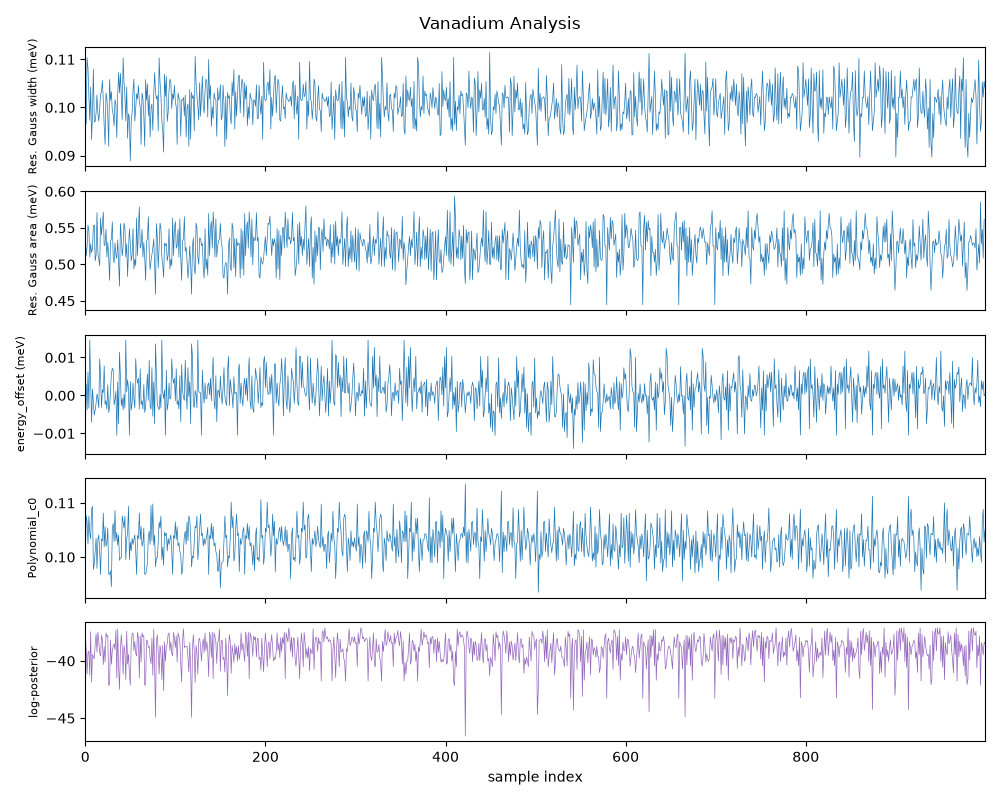

In [7]:
analysis.bayesian.plot_trace()

## Summarize the posterior

`bayesian.summary()` reports the median and the 68% credible interval of each parameter, under the parameter's own name and unit. The interval is asymmetric in general, which is precisely the information a single symmetric error bar throws away.

In [8]:
analysis.bayesian.summary()

PosteriorSummary
parameter              unit         median            -            +        current
-----------------------------------------------------------------------------------
Res. Gauss width        meV        0.10141     0.004738     0.003659        0.10126
Res. Gauss area         meV        0.52556      0.02568      0.02467        0.52992
energy_offset           meV     0.00087272     0.004667     0.004776      0.0012885
Polynomial_c0    dimensionless        0.10309     0.003855     0.002546        0.10237

## Correlations between parameters

The corner plot is the part least available from a least-squares fit. The diagonal shows each parameter's own distribution; each off-diagonal panel shows a pair. A round blob means the two are independent, while a tilted, narrow ridge means they are correlated and the data constrains only a combination of them.

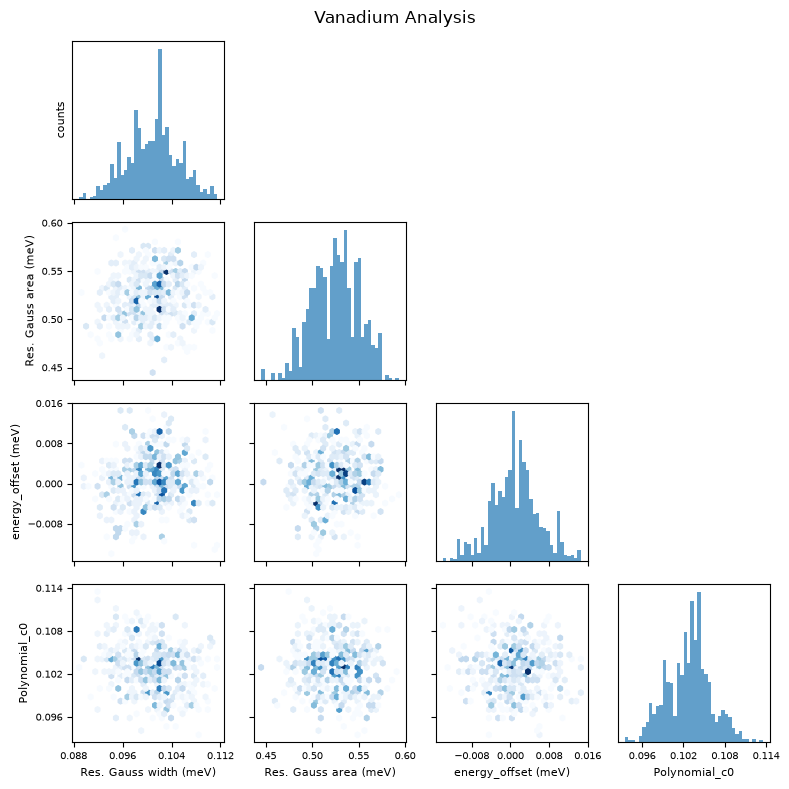

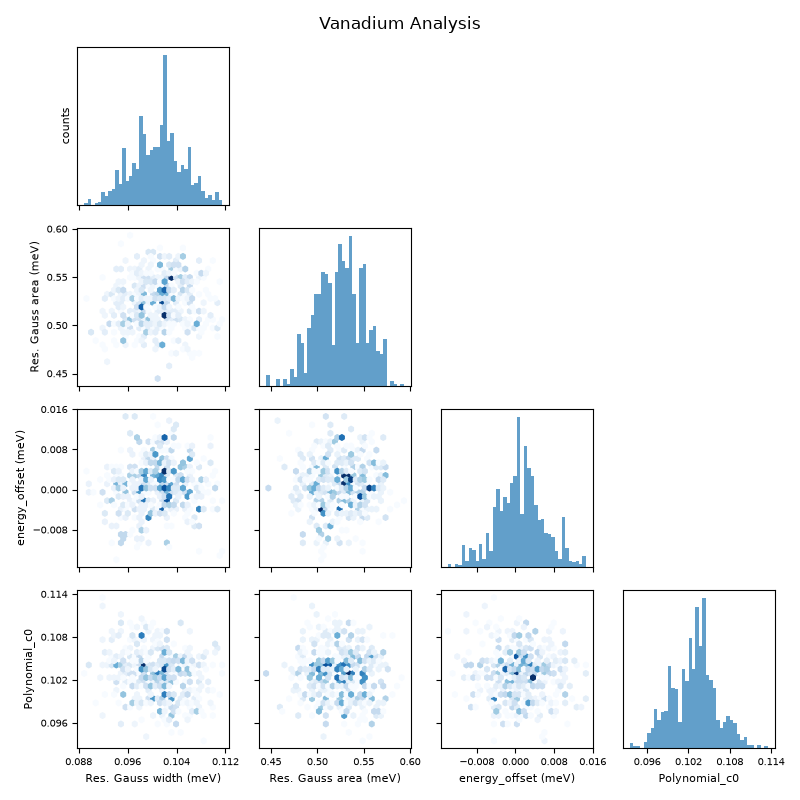

In [9]:
analysis.bayesian.plot_corner()

### One parameter at a time

`plot_marginal()` pulls a single parameter's posterior out of the chain: a histogram of its draws, with the median and the 16/84 percentiles — the same numbers `summary()` reports — marked on it.

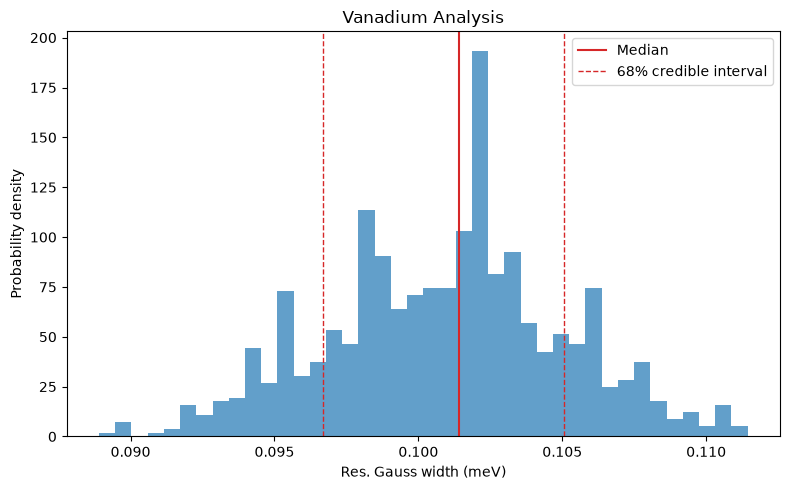

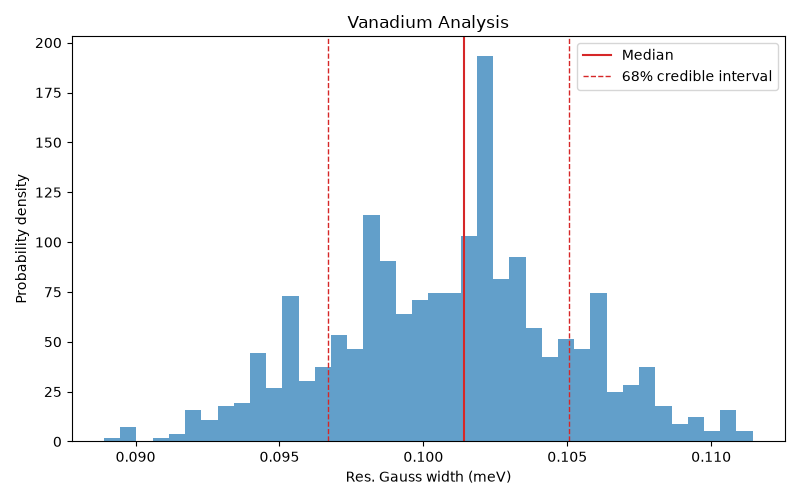

In [10]:
analysis.bayesian.plot_marginal('Res. Gauss width')

### The correlation matrix at a glance

Where the corner plot shows every pairwise distribution, `plot_correlations()` reduces each panel to a single number — the Pearson correlation between the two parameters — and colour-codes the grid. It is the quickest way to spot which parameters the data cannot tell apart.

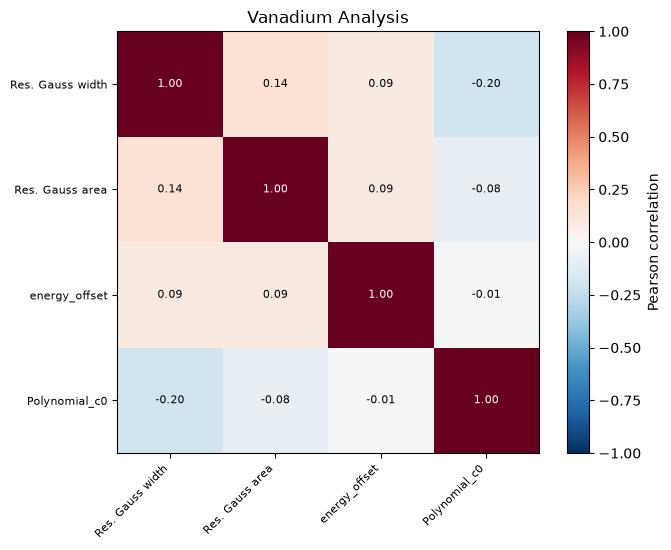

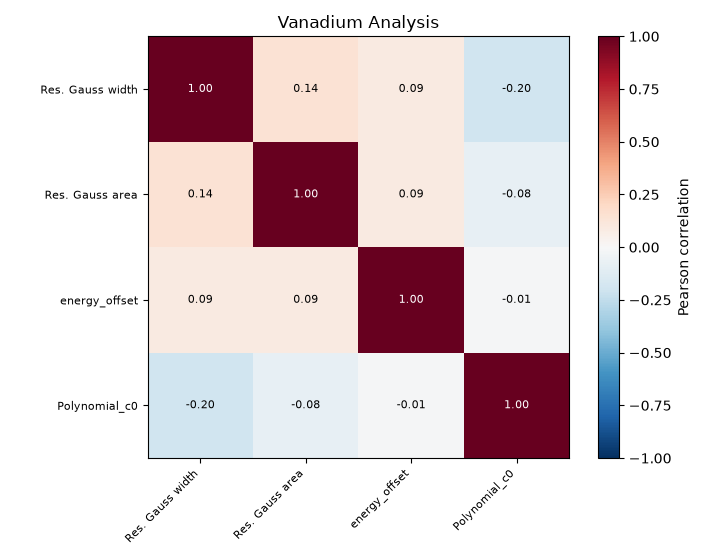

In [11]:
analysis.bayesian.plot_correlations()

## Does the model actually describe the data?

The posterior predictive plot re-evaluates the model for a sample of posterior draws and shades the region they cover. If the data wanders outside the band in a systematic way, the model is missing a feature, and no amount of parameter tuning will fix it.

The band defaults to the 68% credible interval; `credible_interval=95.0` widens it to 95%.

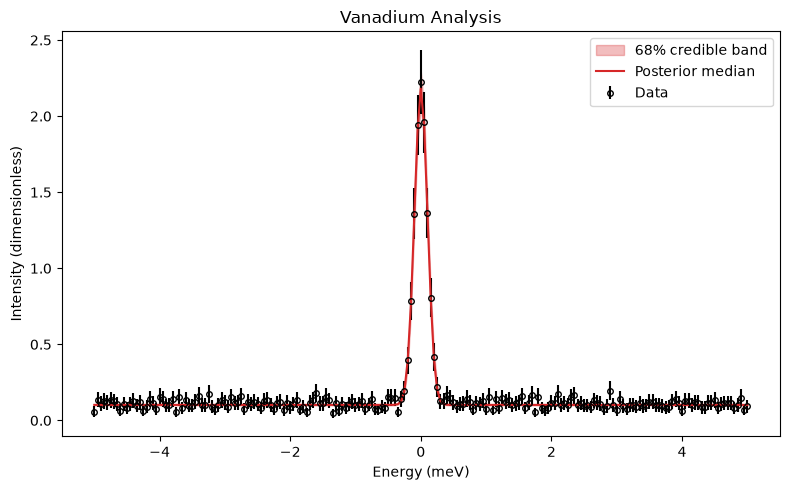

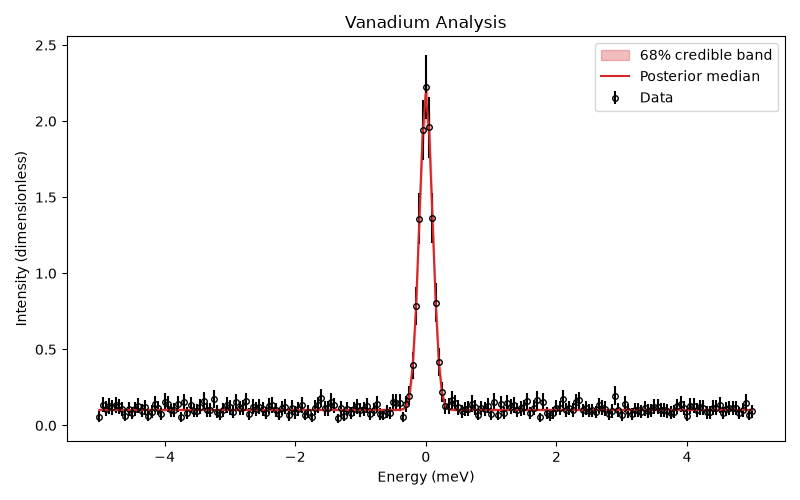

In [12]:
analysis.bayesian.plot_posterior_predictive(n_draws=100)

## Continuing and storing a chain

If the traces suggest the chain needs to run longer, `extend_sampling()` continues the existing chain rather than starting over, so nothing already computed is thrown away.

In [13]:
extended = analysis.bayesian.extend(additional_samples=1000, thin=2)
print(f'Chain now holds {extended.draws.shape[0]} draws.')

Chain now holds 1320 draws.


/home/runner/work/dynamics-lib/dynamics-lib/.pixi/envs/default/lib/python3.14/site-packages/bumps/dream/convergence.py:186: UserWarning: Did not converge!
  warnings.warn("Did not converge!")


Chains are expensive, so they can be saved and reloaded with `analysis.bayesian.save(path)` and `analysis.bayesian.load(path)`. A reloaded chain can be summarized, plotted, or extended further, exactly like a fresh one.

## Several Q values at once

Everything so far used `Analysis1d`, a single Q slice. A full `Analysis` can sample too, either way round:

- `fit_method='independent'` gives each Q its own chain. Cheaper, and the Q values cannot influence one another.
- `fit_method='simultaneous'` runs a single chain over every Q at once, which is what you need when parameters are shared across Q. It costs considerably more, because DREAM runs a number of chains proportional to the parameter count and a simultaneous run has every Q's parameters in play together.

Sampling is much slower than fitting, so it is worth trying a few Q values before committing to all of them. Passing `Q_index` samples just that one.

In [14]:
# Fresh models, so this analysis is independent of the single-Q one above rather than
# sharing its already-sampled components.
all_q_components = edyn.ComponentCollection()
all_q_components.append_component(edyn.Gaussian(width=0.1, area=1, name='Res. Gauss'))

full_analysis = edyn.Analysis(
    display_name='Vanadium, all Q',
    experiment=vanadium_experiment,
    sample_model=edyn.SampleModel(components=all_q_components),
    instrument_model=edyn.InstrumentModel(
        background_model=edyn.BackgroundModel(components=edyn.Polynomial(coefficients=[0.001])),
    ),
)
full_analysis.fit(fit_method='independent')

for Q_index in (4, 8, 12):
    full_analysis.analysis_list[Q_index].bayesian.suggest_bounds().apply()
    full_analysis.bayesian.sample(
        fit_method='independent', Q_index=Q_index, samples=3000, burn=200, thin=2
    )

`bayesian.summary()` gathers the per-Q chains into one table, labelled by Q index. Each row is a marginal distribution, and a marginal is well defined within its own chain, so collecting them says nothing that was not sampled.

In [15]:
full_analysis.bayesian.summary()

PosteriorSummary
parameter                           unit         median            -            +        current
------------------------------------------------------------------------------------------------
Res. Gauss width (Q_index=4)         meV        0.10118     0.003688     0.003044        0.10108
Res. Gauss area (Q_index=4)          meV        0.52333      0.02132      0.02159        0.52764
energy_offset (Q_index=4)            meV     -0.0030682     0.005097     0.004071     -0.0036633
Polynomial_c0 (Q_index=4)     dimensionless        0.10209     0.003384     0.003432        0.10213
Res. Gauss width (Q_index=8)         meV         0.1037     0.003308       0.0043        0.10372
Res. Gauss area (Q_index=8)          meV        0.52907      0.02143      0.02348        0.52914
energy_offset (Q_index=8)            meV     -0.0011883     0.004895     0.004651     -0.0010056
Polynomial_c0 (Q_index=8)     dimensionless       0.096104     0.003003     0.003371        0.09644
Res. Ga

Corner plots are the one thing that cannot be gathered up. The chains were run separately, so no draw pairs a parameter at one Q with a parameter at another, and a combined figure would show correlations that came from how the sampling was run rather than from the data.

So `plot_corner()` steps through them instead. The slider offers only the Q values that were actually sampled — 4, 8 and 12 here — and `plot_corner(Q_index=8)` goes straight to one of them.

In [16]:
full_analysis.bayesian.plot_corner()

The other plots work the same way over independent chains: `plot_posterior_predictive()`, `plot_trace()`, `plot_marginal()` and `plot_correlations()` all show a Q slider in a notebook — the predictive plot through the same slider machinery as `plot_data_and_model()` — take `Q_index=` to go straight to one Q, and outside a notebook name the sampled Q indices instead.

In [17]:
full_analysis.bayesian.plot_posterior_predictive(n_draws=100)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

## Things to watch out for

**Data without uncertainties.** If your data carries no variances, the weights fall back to 1, which means the sampler assumes a noise level of 1 in whatever units the intensity happens to be. Least-squares does not care, since that scale cancels out of the best-fit position, but a posterior *does*: its width scales directly with the assumed noise, so the credible intervals will be wrong by whatever factor the true noise differs from 1. Bayesian analysis is not a way to avoid needing uncertainties on your data.

**Sampling only some parameters.** `bayesian.sample(parameters=[...])` restricts the chain to a subset, which is faster because the number of chains scales with the number of parameters. Be careful with the result: the other parameters are held *fixed*, which is not the same as averaging over them. The intervals you get are conditional on those fixed values, and will be too narrow whenever the parameters are correlated.

**Degenerate parameters.** As seen above, they are a modelling problem rather than a sampling one. `bayesian.suggest_bounds()` returning absurd values, or a warning that the posterior has piled up against its bounds, are both signs to go back and look at the model.

**Several Q values at once.** An `Analysis` can sample either way. `fit_method='independent'` gives each Q its own chain, which is cheaper; `fit_method='simultaneous'` runs one chain over every Q, which is what you need when parameters are shared across Q. `bayesian.summary()` gathers the per-Q chains into one table either way.

Corner plots are the exception. Independent chains share no draws, so nothing pairs a parameter at one Q with a parameter at another, and combining them would show correlations that came from how the sampling was run rather than from the data. `analysis.bayesian.plot_corner()` therefore shows one Q at a time: pass `Q_index`, or leave it out in a notebook to get a slider across the sampled Q values.

**Reproducibility.** Two identical `sample()` calls will not give identical chains: the DREAM backend draws from global random state and exposes no seed. Judge results by whether the summary is stable when the chain is extended, not by exact repetition.